---

# SUBPLOTS

---

>---
>**Subplots** let you create a grid of equally sized charts in a single figure
>
>- `fig, ax = plt.subplots(` `rows`, `columns` `)` - This creates a grid with the specified rows & columns.
>
>---

<br><br>

>---
>Use the **sharex** & **sharey** arguments to **set the same axis limits** an all the plots
>
>- This is set as `False` by default, but can be set to "all", "row", or "col"
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
raw_df = pd.read_csv('../Data/housing_data.csv', parse_dates=['period_begin', 'period_end']).dropna(ignore_index=True)
raw_df.head(3)

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
0,"Johnson County, TX",2019-09-23,2019-12-15,577.0,717.0,778.0,63.0,268737.6,17.095583
1,"Holmes County, OH",2017-10-09,2017-12-31,22.0,52.0,54.0,109.4,115308.3,34.050000
2,"Madison County, FL",2017-01-09,2017-04-02,12.0,54.0,55.0,151.2,158062.5,38.300000


In [3]:
df = (raw_df[raw_df.region_name.str.endswith('CA')]
    .assign(region_name = raw_df.region_name.str[:-11])
    .query("region_name in ['Los Angeles', 'San Diego', 'San Francisco', 'Tulare']")
    .pivot_table(index='period_begin', columns='region_name', 
                 values='median_active_list_price', aggfunc='sum')
)
df

region_name,Los Angeles,San Diego,San Francisco,Tulare
period_begin,,,,
2017-01-02,611561.0,618570.8,1229018.7,225395.8
2017-01-09,614061.0,621737.5,1233393.7,227729.1
2017-01-16,617311.0,625820.8,1239977.0,229060.4
2017-01-23,620644.3,629491.6,1247977.0,229806.2
2017-01-30,624541.6,632824.0,1253310.4,230139.5
...,...,...,...,...
2022-03-28,906783.0,901649.6,1289875.0,387928.9
2022-04-04,906783.1,902899.8,1289916.6,388951.8
2022-04-11,906782.4,902899.8,1290250.0,389863.7


<br><br>

---

# Subplots Example No. 1

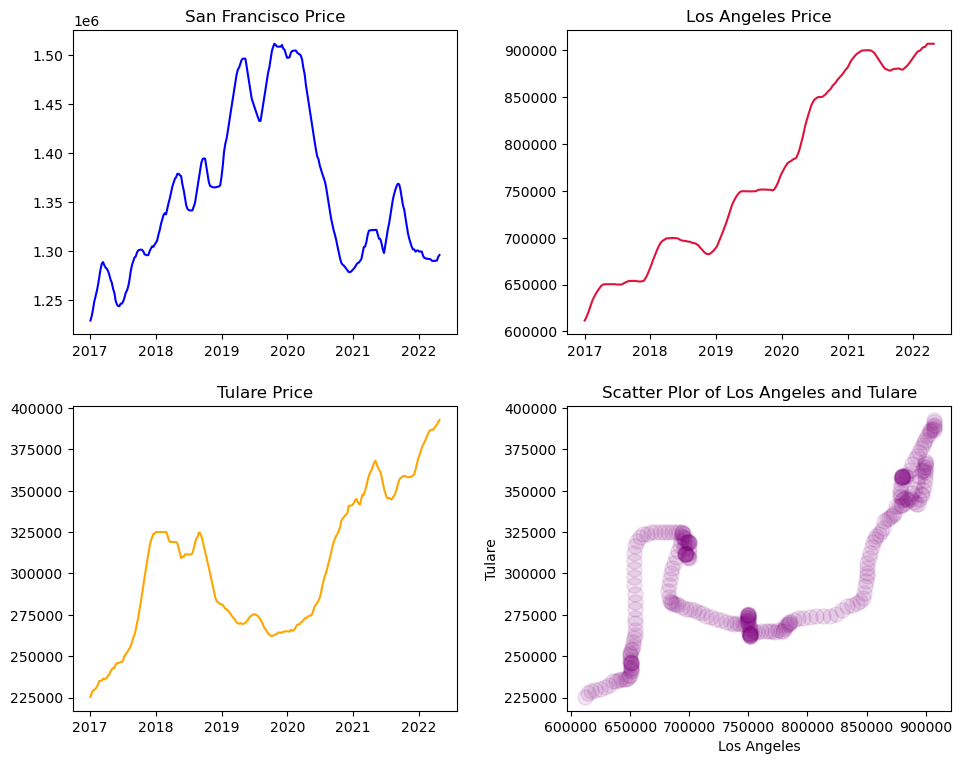

In [4]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,8))

ax[0][0].plot(df.index, df['San Francisco'], color='blue')
ax[0][0].set_title('San Francisco Price')

ax[0][1].plot(df.index, df['Los Angeles'], color='crimson')
ax[0][1].set_title('Los Angeles Price')

ax[1][0].plot(df.index, df['Tulare'], color='orange')
ax[1][0].set_title('Tulare Price')

ax[1][1].scatter(df['Los Angeles'], df['Tulare'], color='purple',
                 alpha=0.1, s=120)
ax[1][1].set_title('Scatter Plor of Los Angeles and Tulare')
ax[1][1].set_xlabel('Los Angeles')
ax[1][1].set_ylabel('Tulare')

plt.tight_layout(pad=2)
plt.show()

<br><br>

---

# Subplots Example No. 2

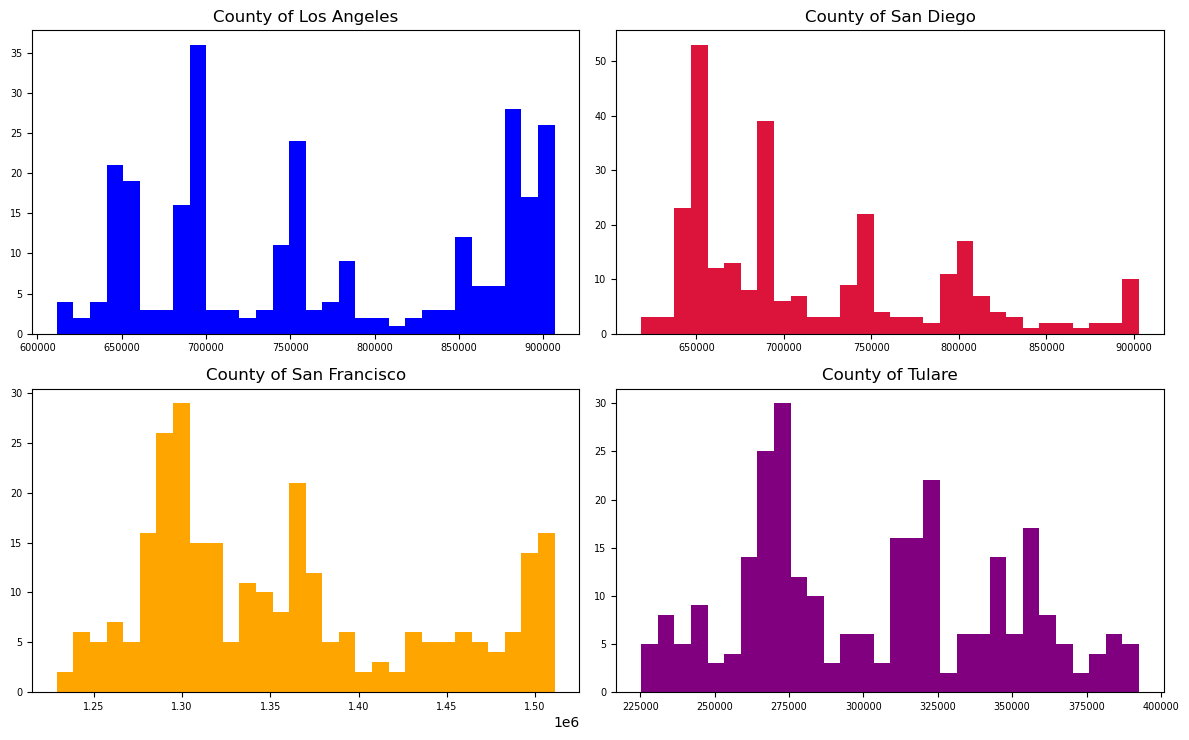

In [5]:
cols = [['Los Angeles', 'San Diego'], ['San Francisco', 'Tulare']]
colorsss=[['blue', 'crimson'], ['orange', 'purple']]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7.5))

for ax, name, colorss  in zip(axes, cols, colorsss):
    for col, county, c in zip(ax, name, colorss):
        col.hist(df[county], label=f'{county}', color=c, bins=30)
        col.set_title(f'County of {county}')
        col.tick_params(axis='both', labelsize=7)


plt.tight_layout()
plt.show()

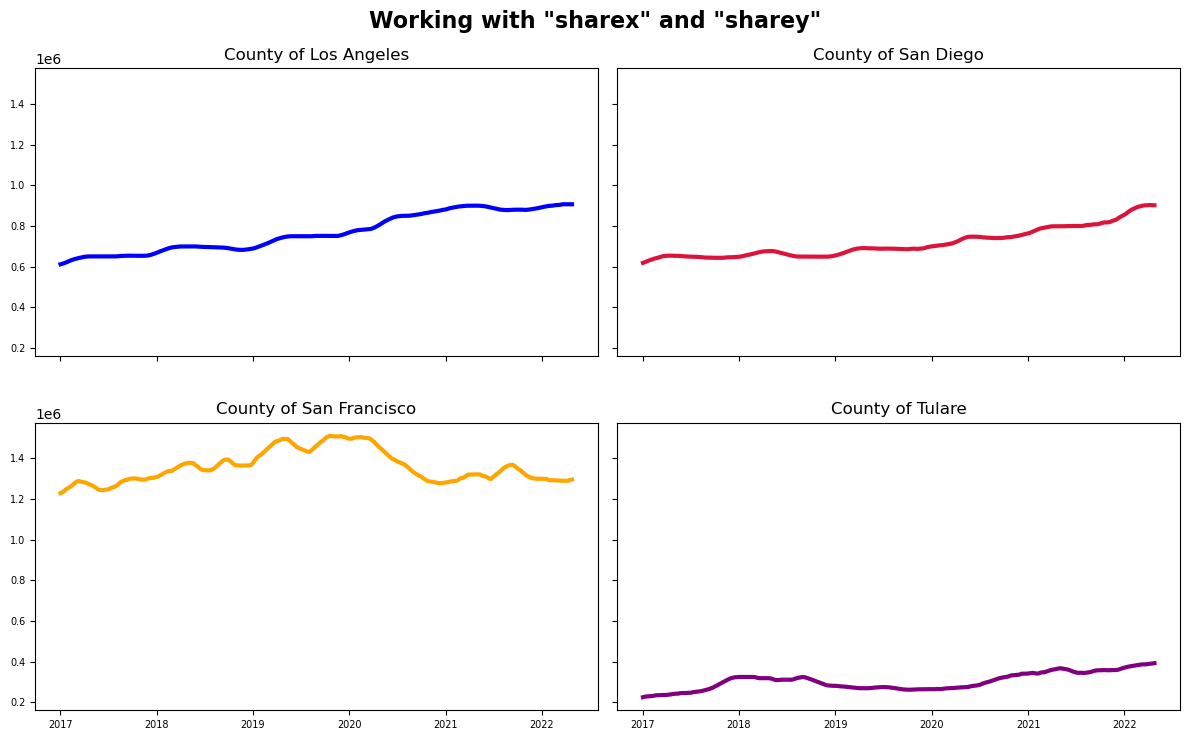

In [6]:
cols = [['Los Angeles', 'San Diego'], ['San Francisco', 'Tulare']]
colorsss=[['blue', 'crimson'], ['orange', 'purple']]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7.5),
                         sharey='all', sharex='all') # Setting all axes at same value

# ------------------------------------------------------------------
for ax, name, colorss  in zip(axes, cols, colorsss):
    for col, county, c in zip(ax, name, colorss):
        col.plot(df.index, df[county], label=f'{county}', 
                 color=c, linewidth=3)
        col.set_title(f'County of {county}')
        col.tick_params(axis='both', labelsize=7)
# ------------------------------------------------------------------

fig.suptitle('Working with "sharex" and "sharey"', fontsize=16, fontweight='bold')
plt.tight_layout(h_pad=3)
plt.show()